In [ ]:
# ── 0. Instalación (ejecutar solo la primera vez) ────────────────────────────
# 1) Reinstala limpio el par numpy+scipy con ABI emparejada (arregla el import roto).
#    numpy<2.3 porque numba (dependencia de pandas_ta 0.4.x) aún no soporta 2.3.
!pip install -q --force-reinstall "numpy<2.3" scipy

# 2) Resto del stack, evitando el salto roto a pandas 3.0.
!pip install -q "pandas<3" numba yfinance pandas_ta torch torchvision

# Reinicia el kernel para que cargue el numpy nuevo desde disco.
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import yfinance as yf
import pandas_ta as ta
from sklearn.preprocessing import MinMaxScaler
# ──────────────────────────────────────────────────────────────────────────────
# PARÁMETROS GLOBALES
# ──────────────────────────────────────────────────────────────────────────────
TICKER        = "^IBEX"
START_DATE    = "2000-01-01"
END_DATE      = "2024-12-31"
STABILITY_END = "2019-12-31"
WINDOW_SIZE   = 30
FEATURE_COLS  = ["Log_Ret", "Volatilidad", "RSI_14", "MACD_12_26_9", "SMA_50"]

TCN_SEQ_LEN   = 10
TCN_CHANNELS  = [32, 16]
TCN_KERNEL    = 3
TCN_DROPOUT   = 0.3

EPOCHS        = 300
LR            = 3e-4
WEIGHT_DECAY  = 1e-3
LABEL_SMOOTH  = 0.05
LAMBDA_REG    = 10.0       # peso de la pérdida de regresión (multitarea)

HORIZON       = 8         # días vista para la dirección
LABEL_THR     = 0.0
COVERAGE      = 0.30       # fracción de días con señal direccional (resto HOLD)

# Filtro de tendencia
GATE_FAST     = 50
GATE_DD_LOOK  = 20
GATE_DD_THR   = -0.08

# Detección de régimen por error de reconstrucción del CNN-AE
RECON_Q       = 0.95       # cuantil del error in-sample que marca el umbral de anomalía

# Colores/etiquetas del semáforo (acción → (color_hex, etiqueta))
SEMAFORO_COLORS = {0: ("#f59e0b", "HOLD"), 1: ("#22c55e", "BUY"), 2: ("#ef4444", "SELL")}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")


Dispositivo: cpu


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. CNN-AE FROZEN
# ══════════════════════════════════════════════════════════════════════════════

class ConvAutoencoder(nn.Module):
    def __init__(self, n_features, seq_len=30):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 32, 3, 1, 1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 16, 3, 2, 1), nn.BatchNorm1d(16), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, 3, 2, 1, output_padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, n_features, 3, 1, 1), nn.Sigmoid(),
        )

    def encode(self, x):       return self.encoder(x.permute(0, 2, 1))
    def get_latent_flat(self, x): return self.encode(x).flatten(1)
    def forward(self, x):      return self.decoder(self.encode(x)).permute(0, 2, 1)


def load_cnn_ae(path, n_features, device):
    m = ConvAutoencoder(n_features)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    return m.to(device)

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. TCN
# ══════════════════════════════════════════════════════════════════════════════

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=0)
    def forward(self, x):
        return self.conv(F.pad(x, (self.pad, 0)))


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
        )
        self.downsample = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.net(x) + self.downsample(x))


class TCN(nn.Module):
    def __init__(self, input_dim, channels, kernel=3, dropout=0.1, output_dim=64):
        super().__init__()
        layers, in_ch = [], input_dim
        for i, out_ch in enumerate(channels):
            layers.append(ResidualTCNBlock(in_ch, out_ch, kernel, 2 ** i, dropout))
            in_ch = out_ch
        self.tcn  = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], output_dim)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.tcn(x)[:, :, -1]
        return self.head(x)


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. AGENTE MULTITAREA: clasificación direccional + regresión de retorno
# ══════════════════════════════════════════════════════════════════════════════

class SemaforoAgent(nn.Module):
    ACTION_NAMES = {0: "HOLD", 1: "BUY", 2: "SELL"}

    def __init__(self, cnn_ae, z_dim=246, tcn_channels=None, tcn_kernel=3,
                 tcn_seq_len=10, dropout=0.3, context_dim=64):
        super().__init__()
        if tcn_channels is None:
            tcn_channels = [32, 16]
        self.cnn_ae = cnn_ae
        self.tcn = TCN(z_dim, tcn_channels, tcn_kernel, dropout, context_dim)
        self.cls = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 3))
        self.reg = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, z):
        ctx = self.tcn(z)
        return self.cls(ctx), self.reg(ctx).squeeze(-1)   # logits (B,3), r_pred (B,)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. DATOS
# ══════════════════════════════════════════════════════════════════════════════

def build_zf_sequences(cnn_ae, X_windows, feat_windows, tcn_seq_len, device, batch_size=256):
    cnn_ae.eval()
    all_z = []
    for i in range(0, len(X_windows), batch_size):
        batch = torch.tensor(X_windows[i:i+batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            all_z.append(cnn_ae.get_latent_flat(batch).cpu().numpy())
    all_z  = np.concatenate(all_z, axis=0).astype(np.float32)
    all_zf = np.concatenate([all_z, feat_windows.astype(np.float32)], axis=1)
    return np.array([all_zf[i:i+tcn_seq_len] for i in range(len(all_zf) - tcn_seq_len)])


def reconstruction_error(cnn_ae, X_windows, device, batch_size=256):
    """
    Error de reconstrucción (MSE por ventana) del CNN-AE congelado.

    El AE se entrena SOLO en el periodo estable (hasta STABILITY_END), de modo
    que reconstruye bien las ventanas "normales" y mal las que no se parecen a
    nada visto en entrenamiento. Un MSE alto = ventana fuera de distribución =
    señal fundamental de CAMBIO DE RÉGIMEN (anomalía de mercado).
    """
    cnn_ae.eval()
    errs = []
    for i in range(0, len(X_windows), batch_size):
        batch = torch.tensor(X_windows[i:i+batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            recon = cnn_ae(batch)                       # (B, seq, feat), mismo shape que batch
            mse = ((recon - batch) ** 2).mean(dim=(1, 2))
        errs.append(mse.cpu().numpy())
    return np.concatenate(errs).astype(np.float32)


def forward_returns(close, decision_offset, n_seqs, horizon):
    c = close.values.astype(np.float64)
    out = []
    for i in range(n_seqs):
        d = decision_offset + i
        if d + horizon >= len(c):
            break
        out.append(np.log(c[d + horizon] / c[d]))
    return np.asarray(out, dtype=np.float32)


def make_labels(fwd, thr=0.0):
    y = np.zeros(len(fwd), dtype=np.int64)
    y[fwd >  thr] = 1
    y[fwd < -thr] = 2
    return y

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. ENTRENAMIENTO MULTITAREA (CE direccional + MSE de retorno)
# ══════════════════════════════════════════════════════════════════════════════

def train_supervised(agent, z_train, fwd_train, r1_train, epochs=300, lr=3e-4,
                     weight_decay=1e-3, thr=0.0, val_frac=0.2, batch_size=128,
                     patience=40, min_epochs=40, label_smoothing=0.05,
                     lambda_reg=10.0, early_stopping=False, device="cpu"):
    y_all = make_labels(fwd_train, thr)
    n_val = int(len(z_train) * val_frac)
    Xtr = torch.as_tensor(z_train[:-n_val], dtype=torch.float32, device=device)
    ytr = torch.as_tensor(y_all[:-n_val],   dtype=torch.long,    device=device)
    rtr = torch.as_tensor(r1_train[:-n_val], dtype=torch.float32, device=device)
    Xva = torch.as_tensor(z_train[-n_val:], dtype=torch.float32, device=device)
    yva = torch.as_tensor(y_all[-n_val:],   dtype=torch.long,    device=device)
    rva = torch.as_tensor(r1_train[-n_val:], dtype=torch.float32, device=device)
    fwd_va = fwd_train[-n_val:]

    params = list(agent.tcn.parameters()) + list(agent.cls.parameters()) + list(agent.reg.parameters())
    opt = Adam(params, lr=lr, weight_decay=weight_decay)

    n = Xtr.shape[0]
    best_loss, best_state, best_ep, bad = float("inf"), None, 0, 0
    val_acc_hist = []
    for ep in range(epochs):
        agent.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            logits, rpred = agent(Xtr[idx])
            loss = (F.cross_entropy(logits, ytr[idx], label_smoothing=label_smoothing)
                    + lambda_reg * F.mse_loss(rpred, rtr[idx]))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0); opt.step()

        agent.eval()
        with torch.no_grad():
            vlogits, vrpred = agent(Xva)
            vloss = (F.cross_entropy(vlogits, yva, label_smoothing=label_smoothing)
                     + lambda_reg * F.mse_loss(vrpred, rva)).item()
            vpred = vlogits.argmax(1).cpu().numpy()
        traded  = (vpred == 1) | (vpred == 2)
        correct = ((vpred == 1) & (fwd_va > 0)) | ((vpred == 2) & (fwd_va < 0))
        vacc = correct[traded].mean() if traded.sum() else float("nan")
        val_acc_hist.append(vacc)

        if vloss < best_loss - 1e-4:
            best_loss, best_ep, bad = vloss, ep, 0
            best_state = {k: v.detach().clone() for k, v in agent.state_dict().items()}
        else:
            bad += 1
        if (ep + 1) % 20 == 0:
            print(f"  Ep {ep+1:>3}/{epochs} | val_loss={vloss:.4f} | val_acc={vacc:.3f}")
        if early_stopping and ep + 1 >= min_epochs and bad >= patience:
            print(f"  Early stopping en epoch {ep+1}")
            break

    if best_state is not None:
        agent.load_state_dict(best_state)
    print(f"  Checkpoint: época {best_ep+1} | val_loss={best_loss:.4f} | val_acc={val_acc_hist[best_ep]:.3f}")
    return val_acc_hist, best_ep

def apply_trend_gate(signals, df, fast=GATE_FAST, dd_look=GATE_DD_LOOK, dd_thr=GATE_DD_THR):
    close = df["Close"]
    sma   = close.rolling(fast).mean()
    ret_r = np.log(close / close.shift(dd_look))
    bullish = ((close > sma) & (ret_r > dd_thr)).reindex(signals.index).fillna(False).values
    act = signals["action"].values.copy()
    act[bullish  & (act == 2)] = 0
    act[~bullish & (act == 1)] = 0
    out = signals.copy()
    out["action"] = act
    out["label"]  = [SEMAFORO_COLORS[a][1] for a in act]
    return out


def evaluate_signals(signals, fwd):
    act = signals["action"].values
    n = len(act); fwd = fwd[:n]
    up, down = fwd > 0, fwd < 0
    bi, se, ho = act == 1, act == 2, act == 0
    traded = bi | se
    correct = (bi & up) | (se & down)
    nt = int(traded.sum())
    pos = np.where(bi, 1.0, np.where(se, -1.0, 0.0))
    return {
        "n_total": n, "n_buy": int(bi.sum()), "n_sell": int(se.sum()), "n_hold": int(ho.sum()),
        "coverage": nt / n if n else float("nan"),
        "dir_accuracy": float(correct[traded].mean()) if nt else float("nan"),
        "precision_buy": (bi & up).sum() / max(int(bi.sum()), 1),
        "precision_sell": (se & down).sum() / max(int(se.sum()), 1),
        "base_up_rate": float(up.mean()),
        "edge_por_senal": float((pos * fwd)[traded].mean()) if nt else float("nan"),
    }


def regression_metrics(pred, true):
    pred, true = np.asarray(pred, float), np.asarray(true, float)
    err = pred - true
    ss_res, ss_tot = np.sum(err ** 2), np.sum((true - true.mean()) ** 2)
    return {
        "R2":   1 - ss_res / ss_tot,
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MAE":  float(np.mean(np.abs(err))),
        "MAPE": float(np.mean(np.abs(err / true)) * 100),
    }


def print_metrics(m, horizon):
    print(f"\n— Acierto direccional (horizonte = {horizon} días) —")
    print(f"   BUY / HOLD / SELL    : {m['n_buy']} / {m['n_hold']} / {m['n_sell']}")
    print(f"   Cobertura (no-ámbar) : {m['coverage']:.3f}")
    print(f"   Accuracy direccional : {m['dir_accuracy']:.3f}")
    print(f"   Precisión BUY        : {m['precision_buy']:.3f}")
    print(f"   Precisión SELL       : {m['precision_sell']:.3f}")
    print(f"   Base 'siempre sube'  : {m['base_up_rate']:.3f}")
    print(f"   Edge medio por señal : {m['edge_por_senal']:+.5f}")


def sweep_coverage(agent, z_test, dates, df, fwd_test, device, recon_anom=None,
                   covs=(0.6, 0.5, 0.4, 0.3, 0.2, 0.1)):
    print("\n— Barrido accuracy vs cobertura (tras filtro de régimen) —")
    print("   cobertura_obj | cobertura_real | accuracy | BUY | SELL")
    for c in covs:
        s = apply_trend_gate(run_inference(agent, z_test, dates, device, coverage=c),
                             df, recon_anomaly=recon_anom)
        m = evaluate_signals(s, fwd_test)
        print(f"        {c:.2f}      |     {m['coverage']:.3f}      |  {m['dir_accuracy']:.3f}  "
              f"| {m['n_buy']:>3} | {m['n_sell']:>3}")


def plot_semaforo(signals, close_prices, title="Semáforo bursátil — IBEX 35"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})
    common = signals.index.intersection(close_prices.index)
    price, sigs = close_prices.loc[common], signals.loc[common]
    ax1.plot(price.index, price.values, color="#1e40af", linewidth=1.2, zorder=3)
    for date, row in sigs.iterrows():
        ax1.axvspan(date, date + pd.Timedelta(days=1),
                    color=SEMAFORO_COLORS[row["action"]][0], alpha=0.18, linewidth=0, zorder=1)
    ax1.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax1.set_ylabel("Precio de cierre"); ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(handles=[
        mpatches.Patch(color="#22c55e", alpha=0.6, label="BUY (sube)"),
        mpatches.Patch(color="#f59e0b", alpha=0.6, label="HOLD (neutro)"),
        mpatches.Patch(color="#ef4444", alpha=0.6, label="SELL (baja)"),
    ], loc="upper left", framealpha=0.9)
    ax2.stackplot(sigs.index, sigs["p_buy"], sigs["p_hold"], sigs["p_sell"],
                  colors=["#22c55e", "#f59e0b", "#ef4444"], alpha=0.75,
                  labels=["P(BUY)", "P(HOLD)", "P(SELL)"])
    ax2.set_ylabel("Probabilidad"); ax2.set_ylim(0, 1)
    ax2.legend(loc="upper right", fontsize=8, framealpha=0.9); ax2.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(); plt.savefig("semaforo_ibex.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Gráfico guardado en semaforo_ibex.png")

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 60)
    print("  CNN-AE + features → TCN → (clasificación + regresión)")
    print("=" * 60)

    print("\n[1/6] Datos...")
    df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    df["Log_Ret"]     = np.log(df["Close"] / df["Close"].shift(1))
    df["Volatilidad"] = df["Log_Ret"].rolling(20).std()
    df.ta.rsi(length=14, append=True); df.ta.macd(append=True); df.ta.sma(length=50, append=True)
    df.dropna(inplace=True)
    print(f"   {df.shape[0]} sesiones ({df.index[0].date()} → {df.index[-1].date()})")

    df["SMA_200"] = df["Close"].rolling(200).mean()
    feat_full = pd.DataFrame(index=df.index)
    feat_full["ret_5"]     = np.log(df["Close"] / df["Close"].shift(5))
    feat_full["ret_20"]    = np.log(df["Close"] / df["Close"].shift(20))
    feat_full["px_sma50"]  = df["Close"] / df["SMA_50"]  - 1.0
    feat_full["px_sma200"] = df["Close"] / df["SMA_200"] - 1.0
    feat_full["rsi"]       = df["RSI_14"] / 100.0
    feat_full["vol"]       = df["Volatilidad"]
    feat_full = feat_full.fillna(0.0)

    full_df  = df[FEATURE_COLS]
    train_df, test_df = full_df[:STABILITY_END], full_df[STABILITY_END:]
    scaler   = MinMaxScaler().fit(train_df)
    train_sc, test_sc = scaler.transform(train_df), scaler.transform(test_df)

    def make_windows(d, ws=WINDOW_SIZE):
        return np.array([d[i:i+ws] for i in range(len(d) - ws)])
    X_train, X_test = make_windows(train_sc), make_windows(test_sc)

    feat_train, feat_test = feat_full.loc[train_df.index], feat_full.loc[test_df.index]
    fmean, fstd = feat_train.mean(), feat_train.std() + 1e-8
    feat_train_sc = ((feat_train - fmean) / fstd).values.astype(np.float32)
    feat_test_sc  = ((feat_test  - fmean) / fstd).values.astype(np.float32)
    fw_train = feat_train_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_train)]
    fw_test  = feat_test_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_test)]
    N_FEAT = fw_train.shape[1]

    print("\n[2/6] CNN-AE...")
    cnn_ae = load_cnn_ae("cnn_ae_weights.pth", n_features=len(FEATURE_COLS), device=DEVICE)
    Z_DIM = 16 * (WINDOW_SIZE // 2) + N_FEAT
    print(f"   z_dim = {Z_DIM} (240 + {N_FEAT})")

    print("\n[3/6] Secuencias y etiquetas...")
    z_train = build_zf_sequences(cnn_ae, X_train, fw_train, TCN_SEQ_LEN, DEVICE)
    z_test  = build_zf_sequences(cnn_ae, X_test,  fw_test,  TCN_SEQ_LEN, DEVICE)

    DEC_OFFSET  = WINDOW_SIZE + TCN_SEQ_LEN - 2
    close_train = df["Close"].loc[train_df.index]
    close_test  = df["Close"].loc[test_df.index]
    fwd_train = forward_returns(close_train, DEC_OFFSET, len(z_train), HORIZON)
    fwd_test  = forward_returns(close_test,  DEC_OFFSET, len(z_test),  HORIZON)
    z_train, z_test = z_train[:len(fwd_train)], z_test[:len(fwd_test)]

    # Retorno del día siguiente (objetivo de la regresión), mismo alineado
    r1_train = forward_returns(close_train, DEC_OFFSET, len(z_train), 1)
    test_dec_dates = test_df.index[DEC_OFFSET: DEC_OFFSET + len(z_test)]
    print(f"   z_train: {z_train.shape} | z_test: {z_test.shape}")

    # ── RÉGIMEN por ERROR DE RECONSTRUCCIÓN del CNN-AE (métrica fundamental) ──
    # El AE se entrenó solo en el periodo estable: umbral = cuantil RECON_Q del
    # error in-sample. En test, error > umbral ⇒ ventana anómala / cambio de régimen.
    recon_train = reconstruction_error(cnn_ae, X_train, DEVICE)
    recon_test  = reconstruction_error(cnn_ae, X_test,  DEVICE)
    recon_thr   = float(np.quantile(recon_train, RECON_Q))
    # Alinear el error con la fecha de DECISIÓN del semáforo:
    #   señal j  ↔  ventana (j + TCN_SEQ_LEN - 1) de X_test
    recon_sig   = recon_test[TCN_SEQ_LEN - 1: TCN_SEQ_LEN - 1 + len(test_dec_dates)]
    recon_anom  = pd.Series(recon_sig > recon_thr,
                            index=test_dec_dates[:len(recon_sig)])
    print(f"   Error recon: umbral(p{int(RECON_Q*100)})={recon_thr:.5f} | "
          f"régimen anómalo {int(recon_anom.sum())}/{len(recon_anom)} "
          f"({recon_anom.mean()*100:.1f}% de los días)")

    plt.figure(figsize=(12, 3))
    plt.plot(recon_anom.index, recon_sig, color="#1e40af", lw=0.9, label="error recon (test)")
    plt.axhline(recon_thr, color="#ef4444", ls="--", lw=1.0, label=f"umbral p{int(RECON_Q*100)}")
    plt.fill_between(recon_anom.index, 0, float(recon_sig.max()),
                     where=recon_anom.values, color="#ef4444", alpha=0.12, label="régimen anómalo")
    plt.title("Error de reconstrucción CNN-AE — detector de régimen")
    plt.ylabel("MSE por ventana"); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig("recon_regime.png", dpi=150); plt.show()

    print("\n[4/6] Agente...")
    agent = SemaforoAgent(cnn_ae, z_dim=Z_DIM, tcn_channels=TCN_CHANNELS,
                          tcn_kernel=TCN_KERNEL, tcn_seq_len=TCN_SEQ_LEN,
                          dropout=TCN_DROPOUT, context_dim=64).to(DEVICE)
    print(f"   Entrenables: {sum(p.numel() for p in agent.parameters() if p.requires_grad):,}")

    print("\n[5/6] Entrenando (multitarea)...")
    history, best_ep = train_supervised(
        agent, z_train, fwd_train, r1_train, epochs=EPOCHS, lr=LR,
        weight_decay=WEIGHT_DECAY, thr=LABEL_THR, label_smoothing=LABEL_SMOOTH,
        lambda_reg=LAMBDA_REG, device=DEVICE)

    plt.figure(figsize=(10, 3))
    plt.plot(history, alpha=0.7, label="val_acc")
    plt.scatter([best_ep], [history[best_ep]], color="red", zorder=5, label=f"checkpoint ({history[best_ep]:.3f})")
    plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
    plt.title("Accuracy de validación"); plt.xlabel("Época"); plt.ylabel("val_acc"); plt.legend()
    plt.tight_layout(); plt.savefig("tcn_training_curve.png", dpi=150); plt.show()

    print("\n[6/6] Inferencia, semáforo y métricas...")
    signals = apply_trend_gate(
        run_inference(agent, z_test, test_dec_dates, DEVICE, coverage=COVERAGE),
        df, recon_anomaly=recon_anom)
    print("\nDistribución de señales:")
    print(signals["label"].value_counts())
    print_metrics(evaluate_signals(signals, fwd_test), HORIZON)

    # ── Métricas de REGRESIÓN sobre el precio del día siguiente (comparables al paper)
    c = close_test.values
    d_idx = DEC_OFFSET + np.arange(len(signals))
    pred_price  = c[d_idx] * np.exp(signals["r_pred"].values)
    true_price  = c[d_idx + 1]
    naive_price = c[d_idx]                       # persistencia: "mañana = hoy"
    reg   = regression_metrics(pred_price,  true_price)
    naive = regression_metrics(naive_price, true_price)
    print("\n— Regresión del precio (día siguiente) —")
    print(f"   Modelo      : R²={reg['R2']:.4f} | RMSE={reg['RMSE']:.2f} | "
          f"MAE={reg['MAE']:.2f} | MAPE={reg['MAPE']:.3f}%")
    print(f"   Persistencia: R²={naive['R2']:.4f} | RMSE={naive['RMSE']:.2f} | "
          f"MAE={naive['MAE']:.2f} | MAPE={naive['MAPE']:.3f}%")
    print("   (un R²~0.98 es trivial: el baseline 'mañana=hoy' lo iguala)")

    # ── Barrido para acercar la accuracy a 0.65 bajando cobertura
    sweep_coverage(agent, z_test, test_dec_dates, df, fwd_test, DEVICE, recon_anom=recon_anom)

    plot_semaforo(signals, close_test, title=f"Semáforo bursátil — {TICKER}")
    print("\n¡Pipeline completo!")
    return agent, signals


def run_inference(agent, z_sequences, dates, device, coverage=0.50,
                  q_low=None, q_high=None):
    """
    Asignación por RANGO de la señal alcista s = P(BUY) - P(SELL):
      - los k = coverage/2 · N días con s MÁS ALTO  → BUY
      - los k = coverage/2 · N días con s MÁS BAJO  → SELL
      - el resto → HOLD
    Usar el rango (y no umbrales por valor) GARANTIZA que se operen exactamente
    `coverage`·N días, aunque el modelo colapse y s sea casi constante.
    """
    agent.eval()
    P, R = [], []
    for i in range(len(z_sequences)):
        x = torch.tensor(z_sequences[i], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, rpred = agent(x)
            P.append(F.softmax(logits, dim=-1).squeeze().cpu().numpy())
            R.append(float(rpred.squeeze().cpu()))
    P = np.array(P)                         # columnas: [HOLD, BUY, SELL]
    R = np.array(R, dtype=np.float32)       # retorno log previsto a 1 día
    score = P[:, 1] - P[:, 2]               # señal alcista
    n = len(score)

    actions = np.zeros(n, dtype=np.int64)   # 0 = HOLD por defecto
    if q_low is not None and q_high is not None:
        lo, hi = np.quantile(score, [q_low, q_high])
        actions = np.where(score >= hi, 1, np.where(score <= lo, 2, 0))
    else:
        coverage = float(np.clip(coverage, 0.0, 1.0))
        k_tot  = int(round(n * coverage))
        k_buy  = k_tot // 2
        k_sell = k_tot - k_buy
        order  = np.argsort(score, kind="stable")   # ascendente
        if k_buy  > 0: actions[order[-k_buy:]] = 1   # k mayores → BUY
        if k_sell > 0: actions[order[:k_sell]] = 2   # k menores → SELL

    return pd.DataFrame({
        "date" : dates[:len(actions)],
        "action": actions,
        "label" : [SEMAFORO_COLORS[a][1] for a in actions],
        "p_hold": P[:, 0], "p_buy": P[:, 1], "p_sell": P[:, 2],
        "r_pred": R[:len(actions)],
    }).set_index("date")


def apply_trend_gate(signals, df, recon_anomaly=None,
                     fast=50, dd_lookback=20, dd_thresh=-0.08):
    """
    Detección de RÉGIMEN. La métrica FUNDAMENTAL es el ERROR DE RECONSTRUCCIÓN
    del CNN-AE (parámetro `recon_anomaly`, booleano alineado a signals.index):
    el AE se entrenó en el periodo estable, así que un error alto = la ventana
    actual está fuera de distribución = cambio de régimen.

    El error de reconstrucción es DIRECCIONALMENTE NEUTRO: dice "esto es raro",
    no "sube o baja". Por eso se combina con la SMA(fast), que aporta la
    dirección, y con el override de drawdown como red de seguridad secundaria:
      - Régimen normal (recon bajo) Y precio > SMA  → alcista → SELL→HOLD.
      - Régimen anómalo (recon alto) O precio < SMA → bajista → BUY→HOLD.
    Si recon_anomaly es None, el gate degrada al comportamiento previo (solo
    tendencia + drawdown).
    """
    close = df["Close"]
    sma   = close.rolling(fast).mean()
    ret_r = np.log(close / close.shift(dd_lookback))

    # Componente direccional (tendencia) + red de seguridad de drawdown
    trend_bullish = (close > sma) & (ret_r > dd_thresh)
    trend_bullish = trend_bullish.reindex(signals.index).fillna(False).values

    # Métrica fundamental: error de reconstrucción → régimen normal vs anómalo
    if recon_anomaly is not None:
        anom = pd.Series(recon_anomaly).reindex(signals.index).fillna(False).values.astype(bool)
    else:
        anom = np.zeros(len(signals), dtype=bool)

    # Alcista solo si la tendencia es alcista Y el régimen NO es anómalo
    bullish = trend_bullish & (~anom)

    act = signals["action"].values.copy()
    #act[bullish  & (act == 2)] = 0   # en régimen alcista no shortear
    #act[~bullish & (act == 1)] = 0   # en régimen bajista/anómalo no comprar
    act[anom & (act == 1)] = 0   # solo bloquea BUY en régimen anómalo; deja pasar todo lo demás
    out = signals.copy()
    out["action"] = act
    out["label"]  = [SEMAFORO_COLORS[a][1] for a in act]
    return out


def evaluate_signals(signals: pd.DataFrame, fwd: np.ndarray) -> dict:
    act = signals["action"].values
    n   = len(act)
    fwd = fwd[:n]
    really_up, really_down = fwd > 0, fwd < 0
    is_buy, is_sell, is_hold = act == 1, act == 2, act == 0
    traded  = is_buy | is_sell
    correct = (is_buy & really_up) | (is_sell & really_down)
    n_traded = int(traded.sum())
    pos = np.where(is_buy, 1.0, np.where(is_sell, -1.0, 0.0))
    return {
        "n_total": n, "n_buy": int(is_buy.sum()), "n_sell": int(is_sell.sum()),
        "n_hold": int(is_hold.sum()),
        "coverage": n_traded / n if n else float("nan"),
        "dir_accuracy": float(correct[traded].mean()) if n_traded else float("nan"),
        "precision_buy": (is_buy & really_up).sum() / max(int(is_buy.sum()), 1),
        "precision_sell": (is_sell & really_down).sum() / max(int(is_sell.sum()), 1),
        "base_up_rate": float(really_up.mean()),
        "edge_por_senal": float((pos * fwd)[traded].mean()) if n_traded else float("nan"),
    }


def print_metrics(m, horizon):
    print(f"\nMétricas de acierto (horizonte = {horizon} días):")
    print(f"   Señales totales      : {m['n_total']}")
    print(f"   BUY / HOLD / SELL    : {m['n_buy']} / {m['n_hold']} / {m['n_sell']}")
    print(f"   Cobertura (no-ámbar) : {m['coverage']:.3f}")
    print(f"   Accuracy direccional : {m['dir_accuracy']:.3f}")
    print(f"   Precisión BUY        : {m['precision_buy']:.3f}")
    print(f"   Precisión SELL       : {m['precision_sell']:.3f}")
    print(f"   Base 'siempre sube'  : {m['base_up_rate']:.3f}   (listón a batir)")
    print(f"   Edge medio por señal : {m['edge_por_senal']:+.5f}")


def plot_semaforo(signals, close_prices, title="Semáforo bursátil — IBEX 35"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                   gridspec_kw={"height_ratios": [3, 1]})
    common = signals.index.intersection(close_prices.index)
    price, sigs = close_prices.loc[common], signals.loc[common]
    ax1.plot(price.index, price.values, color="#1e40af", linewidth=1.2, zorder=3)
    for date, row in sigs.iterrows():
        ax1.axvspan(date, date + pd.Timedelta(days=1),
                    color=SEMAFORO_COLORS[row["action"]][0], alpha=0.18, linewidth=0, zorder=1)
    ax1.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax1.set_ylabel("Precio de cierre"); ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(handles=[
        mpatches.Patch(color="#22c55e", alpha=0.6, label="BUY (sube)"),
        mpatches.Patch(color="#f59e0b", alpha=0.6, label="HOLD (neutro)"),
        mpatches.Patch(color="#ef4444", alpha=0.6, label="SELL (baja)"),
    ], loc="upper left", framealpha=0.9)
    ax2.stackplot(sigs.index, sigs["p_buy"], sigs["p_hold"], sigs["p_sell"],
                  colors=["#22c55e", "#f59e0b", "#ef4444"], alpha=0.75,
                  labels=["P(BUY)", "P(HOLD)", "P(SELL)"])
    ax2.set_ylabel("Probabilidad"); ax2.set_ylim(0, 1)
    ax2.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(); plt.savefig("semaforo_ibex.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Gráfico guardado en semaforo_ibex.png")


[*********************100%***********************]  1 of 1 completed

  CNN-AE + features → TCN → (clasificación + regresión)

[1/6] Datos...
   6308 sesiones (2000-03-13 → 2024-12-30)

[2/6] CNN-AE...
   z_dim = 246 (240 + 6)

[3/6] Secuencias y etiquetas...


   z_train: (4982, 10, 246) | z_test: (1235, 10, 246)
   Error recon: umbral(p95)=0.00064 | régimen anómalo 213/1235 (17.2% de los días)


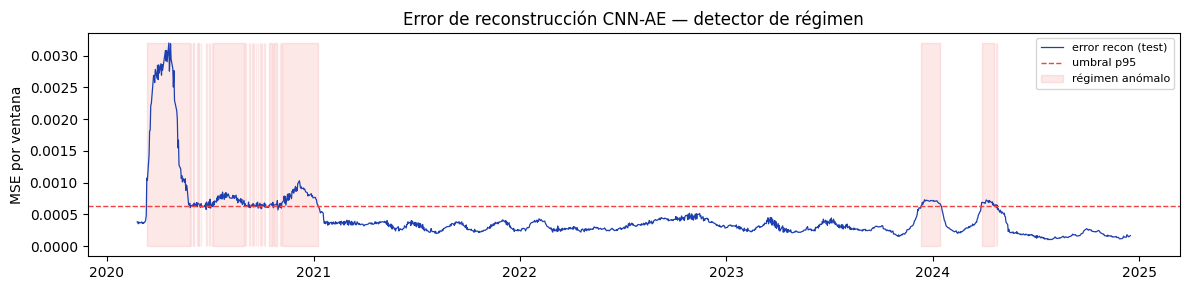


[4/6] Agente...
   Entrenables: 47,380

[5/6] Entrenando (multitarea)...
  Ep  20/300 | val_loss=0.9062 | val_acc=0.499
  Ep  40/300 | val_loss=1.0684 | val_acc=0.517
  Ep  60/300 | val_loss=1.3027 | val_acc=0.515
  Ep  80/300 | val_loss=1.1977 | val_acc=0.515
  Ep 100/300 | val_loss=1.2524 | val_acc=0.510
  Ep 120/300 | val_loss=1.3677 | val_acc=0.510
  Ep 140/300 | val_loss=1.3222 | val_acc=0.526
  Ep 160/300 | val_loss=1.3335 | val_acc=0.520
  Ep 180/300 | val_loss=1.4111 | val_acc=0.511
  Ep 200/300 | val_loss=1.3594 | val_acc=0.527
  Ep 220/300 | val_loss=1.3492 | val_acc=0.519
  Ep 240/300 | val_loss=1.5608 | val_acc=0.519
  Ep 260/300 | val_loss=1.4579 | val_acc=0.486
  Ep 280/300 | val_loss=1.5444 | val_acc=0.515
  Ep 300/300 | val_loss=1.4629 | val_acc=0.517
  Checkpoint: época 3 | val_loss=0.7689 | val_acc=0.521


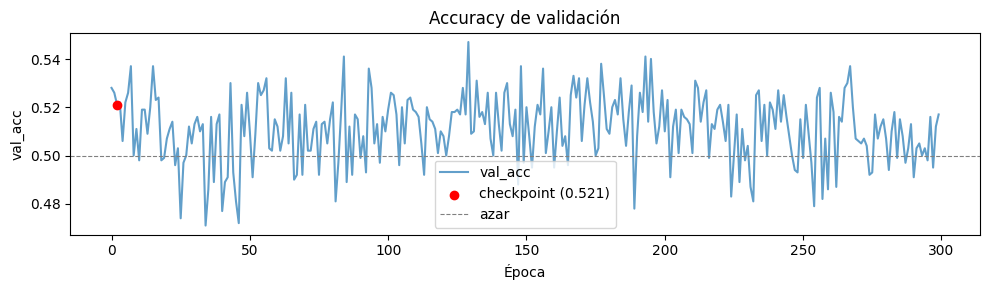


[6/6] Inferencia, semáforo y métricas...

Distribución de señales:
label
HOLD    928
SELL    185
BUY     122
Name: count, dtype: int64

Métricas de acierto (horizonte = 8 días):
   Señales totales      : 1235
   BUY / HOLD / SELL    : 122 / 928 / 185
   Cobertura (no-ámbar) : 0.249
   Accuracy direccional : 0.557
   Precisión BUY        : 0.672
   Precisión SELL       : 0.481
   Base 'siempre sube'  : 0.561   (listón a batir)
   Edge medio por señal : +0.00356

— Regresión del precio (día siguiente) —
   Modelo      : R²=0.9873 | RMSE=148.99 | MAE=116.77 | MAPE=1.362%
   Persistencia: R²=0.9934 | RMSE=107.07 | MAE=76.61 | MAPE=0.897%
   (un R²~0.98 es trivial: el baseline 'mañana=hoy' lo iguala)

— Barrido accuracy vs cobertura (tras filtro de régimen) —
   cobertura_obj | cobertura_real | accuracy | BUY | SELL
        0.60      |     0.513      |  0.503  | 263 | 371
        0.50      |     0.428      |  0.516  | 220 | 309
        0.40      |     0.339      |  0.558  | 172 | 247
     

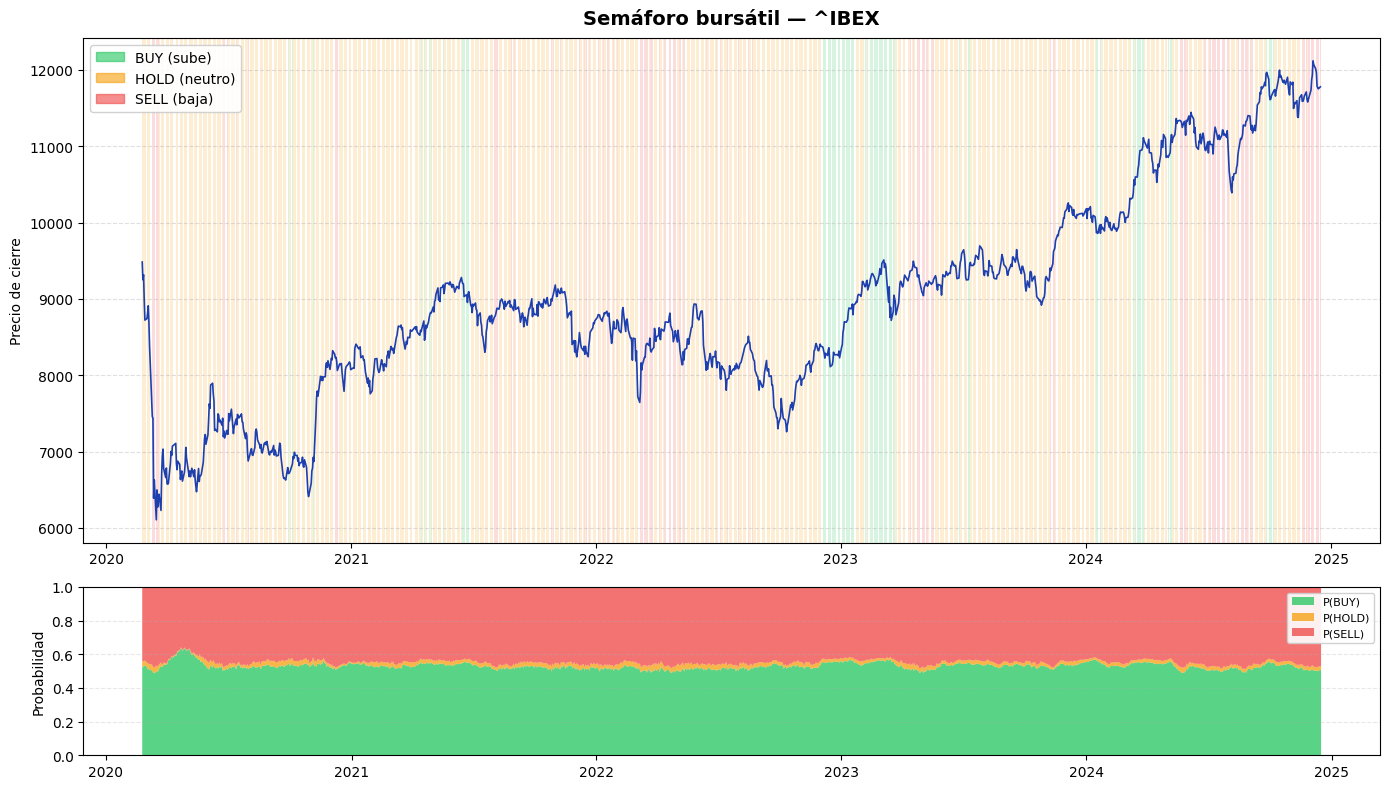

Gráfico guardado en semaforo_ibex.png

¡Pipeline completo!


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# EJECUCIÓN
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    main()
